# Kickstarter Data Analysis

**Name:** Rona Zhang  
**Date:** 03/11/2026

## Introduction

Kickstarter is a reward-based crowdfunding platform founded in 2009 that connects creators with backers through an all-or-nothing funding model. Creators launch projects by setting a funding goal and campaign duration, while backers pledge financial support in exchange for rewards. Projects only receive funding if the pledged amount meets or exceeds the stated goal. Over the years, Kickstarter has supported a wide range of projects across categories such as technology, games, film, design, and publishing.

This report aims to explore the characteristics of Kickstarter campaigns through data analysis. Specifically, it investigates factors associated with project success, differences across categories, funding goal structures, and time-based trends in campaign performance. By applying exploratory data analysis and time series techniques, the report seeks to provide insights into how campaign attributes relate to funding outcomes.

## 1. Data Overview and Initial Screening


### 1.1 Dataset Structure

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Kickstarter.csv')
df.head()

,ID,name,category,main_category,deadline,launched,pledged,state,backers,country,usd_pledged_real,usd_goal_real
0,1000002330,The Songs of Adelaide & Abullah,Poetry,Publishing,10/9/15,8/11/15 12:12,0.0,failed,0,GB,0.0,1533.95
1,1000003930,Greeting From Earth: ZGAC Arts Capsule For ET,Narrative Film,Film & Video,11/1/17,9/2/17 4:43,2421.0,failed,15,US,2421.0,30000.00
2,1000004038,Where is Hank?,Narrative Film,Film & Video,2/26/13,1/12/13 0:20,220.0,failed,3,US,220.0,45000.00
3,1000007540,ToshiCapital Rekordz Needs Help to Complete Album,Music,Music,4/16/12,3/17/12 3:24,1.0,failed,1,US,1.0,5000.00
4,1000011046,Community Film Project: The Art of Neighborhoo...,Film & Video,Film & Video,8/29/15,7/4/15 8:35,1283.0,canceled,14,US,1283.0,19500.00


In [2]:
# Dataset shape
print("Dataset shape (rows, columns):", df.shape)

# Dataset information
df.info()

Dataset shape (rows, columns): (378661, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 378661 entries, 0 to 378660
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   ID                378661 non-null  int64  
 1   name              378657 non-null  object 
 2   category          378661 non-null  object 
 3   main_category     378661 non-null  object 
 4   deadline          378661 non-null  object 
 5   launched          378661 non-null  object 
 6   pledged           378661 non-null  float64
 7   state             378661 non-null  object 
 8   backers           378661 non-null  int64  
 9   country           378661 non-null  object 
 10  usd_pledged_real  378661 non-null  float64
 11  usd_goal_real     378661 non-null  float64
dtypes: float64(3), int64(2), object(7)
memory usage: 34.7+ MB


In [3]:
# Descriptive statistics for numeric variables
df.describe()

,ID,pledged,backers,usd_pledged_real,usd_goal_real
count,3.786610e+05,3.786610e+05,378661.000000,3.786610e+05,3.786610e+05
mean,1.074731e+09,9.682979e+03,105.617476,9.058924e+03,4.545440e+04
std,6.190862e+08,9.563601e+04,907.185035,9.097334e+04,1.152950e+06
min,5.971000e+03,0.000000e+00,0.000000,0.000000e+00,1.000000e-02
25%,5.382635e+08,3.000000e+01,2.000000,3.100000e+01,2.000000e+03
50%,1.075276e+09,6.200000e+02,12.000000,6.243300e+02,5.500000e+03
75%,1.610149e+09,4.076000e+03,56.000000,4.050000e+03,1.550000e+04
max,2.147476e+09,2.033899e+07,219382.000000,2.033899e+07,1.663614e+08


In [4]:
# Check unique values in key categorical variables
df['state'].value_counts()

state
failed        197719
successful    133956
canceled       38779
undefined       3562
live            2799
suspended       1846
Name: count, dtype: int64

In [5]:
df['main_category'].value_counts()

main_category
Film & Video    63585
Music           51918
Publishing      39874
Games           35231
Technology      32569
Design          30070
Art             28153
Food            24602
Fashion         22816
Theater         10913
Comics          10819
Photography     10779
Crafts           8809
Journalism       4755
Dance            3768
Name: count, dtype: int64

In [6]:
df['country'].value_counts()

country
US      292627
GB       33672
CA       14756
AU        7839
DE        4171
N,0"      3797
FR        2939
IT        2878
NL        2868
ES        2276
SE        1757
MX        1752
NZ        1447
DK        1113
IE         811
CH         761
NO         708
HK         618
BE         617
AT         597
SG         555
LU          62
JP          40
Name: count, dtype: int64

The dataset contains 378,661 Kickstarter projects and 12 variables. Each row represents one crowdfunding campaign.

The variables are structured as follows:

- **Numeric variables (5):** ID, pledged, backers, usd_pledged_real, usd_goal_real  
- **Categorical variables (7):** name, category, main_category, deadline, launched, state, country  

At this stage, `deadline` and `launched` are stored as object types and will be converted to datetime format in the data cleaning step.

**Key Variables**

- **usd_goal_real:** Funding target (USD).  
- **usd_pledged_real:** Total pledged amount (USD).  
- **state:** Project outcome (failed, successful, canceled, etc.).  
- **main_category:** Major project classification.  
- **backers:** Number of supporters.


Descriptive statistics indicate substantial variability in financial variables.  
The median funding goal is $5,500, while the maximum goal exceeds \$166 million, suggesting a highly right-skewed distribution with extreme outliers.

Similarly, pledged amounts range from $0 to over \$20 million, further confirming the presence of large variability.

- **state:** Failed projects (197,719) exceed successful projects (133,956), indicating that a majority of campaigns do not reach their funding goals.

- **main_category:** Film & Video (63,585) and Music (51,918) are the largest categories, suggesting strong creator participation in creative media-related projects.

- **country:** The majority of projects originate from the United States (292,627), indicating a strong geographic concentration of Kickstarter activity.

### 1.2 Data Quality Check

Check duplicates

In [7]:
# Check duplicate rows
df.duplicated().sum()

np.int64(0)

Check missing values

In [8]:
# Check missing values
print("Missing values per column:")
display(df.isnull().sum())

Missing values per column:


ID                  0
name                4
category            0
main_category       0
deadline            0
launched            0
pledged             0
state               0
backers             0
country             0
usd_pledged_real    0
usd_goal_real       0
dtype: int64

In [9]:
# Drop rows with missing project names
df = df.dropna(subset=['name'])

# Verify
df.isnull().sum()

ID                  0
name                0
category            0
main_category       0
deadline            0
launched            0
pledged             0
state               0
backers             0
country             0
usd_pledged_real    0
usd_goal_real       0
dtype: int64

Fix corrupted country code

In [10]:
# Replace corrupted country code
df['country'] = df['country'].replace('N,0"', 'Unknown')

# Verify replacement
df['country'].value_counts()

country
US         292624
GB          33671
CA          14756
AU           7839
DE           4171
Unknown      3797
FR           2939
IT           2878
NL           2868
ES           2276
SE           1757
MX           1752
NZ           1447
DK           1113
IE            811
CH            761
NO            708
HK            618
BE            617
AT            597
SG            555
LU             62
JP             40
Name: count, dtype: int64

Convert datetime variables

In [11]:
# Convert to datetime
df['launched'] = pd.to_datetime(df['launched'], errors='coerce', format='mixed')
df['deadline'] = pd.to_datetime(df['deadline'], errors='coerce', format='mixed')

# Verify conversion
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 378657 entries, 0 to 378660
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   ID                378657 non-null  int64         
 1   name              378657 non-null  object        
 2   category          378657 non-null  object        
 3   main_category     378657 non-null  object        
 4   deadline          378657 non-null  datetime64[ns]
 5   launched          378657 non-null  datetime64[ns]
 6   pledged           378657 non-null  float64       
 7   state             378657 non-null  object        
 8   backers           378657 non-null  int64         
 9   country           378657 non-null  object        
 10  usd_pledged_real  378657 non-null  float64       
 11  usd_goal_real     378657 non-null  float64       
dtypes: datetime64[ns](2), float64(3), int64(2), object(5)
memory usage: 37.6+ MB


Outlier Identification (IQR Method)

In [12]:
# IQR method for usd_goal_real
Q1 = df['usd_goal_real'].quantile(0.25)
Q3 = df['usd_goal_real'].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: -18250.0
Upper Bound: 35750.0


In [13]:
high_outliers = df[(df['usd_goal_real'] > upper_bound)]
low_outliers = [(df['usd_goal_real'] < lower_bound)]
print("Number of high outliers:", len(high_outliers))
print("Number of low outliers:", len(low_outliers))

Number of high outliers: 45507
Number of low outliers: 1


The IQR method identifies $35,750 as the upper threshold for extreme funding goals, with 45507 projects exceeding this value.

This confirms that the funding goal variable is heavily right-skewed, with a large number of high-goal projects influencing the overall distribution.

In [14]:
# Check the year to see if there is any mistake year
df['launched'].dt.year.value_counts().sort_index()

launched
2009     1329
2010    10519
2011    26236
2012    41163
2013    44851
2014    67745
2015    77300
2016    57183
2017    52200
2018      124
2070        7
Name: count, dtype: int64

We found that a small number of projects were found with launch years of 2070, which is inconsistent with the reality. So these observations should be treated as data anomalies and removed to ensure accurate analysis.

In [15]:
# Remove anomalous future launch dates
df = df[df['launched'].dt.year <= 2018]

## 2. Data Wrangling and Visualization

### Goal Category Creation

To facilitate comparison and reduce the influence of extreme funding goals, the variable `usd_goal_real` was categorized into three groups:

- Low: under \$5,000  
- Medium: \$5,000 to \$20,000  
- High: above \$20,000  


In [16]:
# Create goal categories using usd_goal_real
bins = [0, 5000, 20000, df['usd_goal_real'].max()]
labels = ['Low', 'Medium', 'High']
df['goal_category'] = pd.cut(df['usd_goal_real'],
                             bins=bins,
                             labels=labels,
                             include_lowest=True)
# Check distribution
df['goal_category'].value_counts()

goal_category
Low       186775
Medium    116561
High       75314
Name: count, dtype: int64

To narrow the scope of analysis and reduce the influence of extreme high-goal projects, **all subsequent visualizations and time series analyses will focus on the Medium funding goal category (\$5,000-\$20,000)**. The Medium range represents typical Kickstarter campaign targets and captures a substantial portion of projects while avoiding the volatility introduced by very high or low funding goals. So focusing on this group allows for more stable comparisons, clearer distributional patterns, and more reliable time series modeling.

In [17]:
# Filter medium goal projects
df_medium = df[df['goal_category']== 'Medium']

### 2.1 Distribution & Comparison


#### 2.1.1 Funding Goals Between Completed Campaigns

To **compare funding goals between completed campaigns in Medium goal category**, we need to filter the dataset to include only projects with outcomes labeled as "successful" or "failed", as other states such as "live" or "canceled" do not represent finalized funding outcomes.

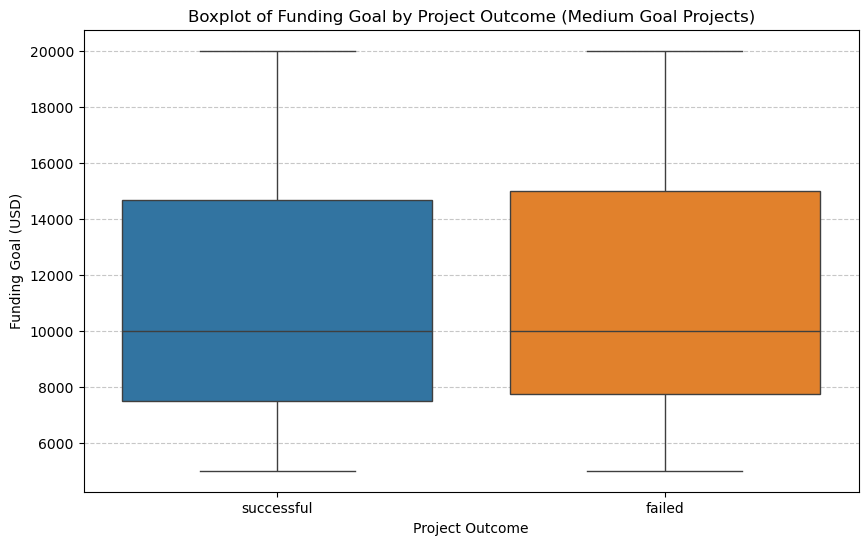

In [18]:
# Filter only completed projects (successful and failed)
df_completed = df_medium[df_medium['state'].isin(['successful', 'failed'])]

# Create boxplot
plt.figure(figsize=(10,6))
sns.boxplot(y='usd_goal_real', x='state', hue='state', data=df_completed)

plt.title('Boxplot of Funding Goal by Project Outcome (Medium Goal Projects)')
plt.ylabel('Funding Goal (USD)')
plt.xlabel('Project Outcome')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Key Findings**

- Within the Medium goal category, both successful and failed projects display similar median funding goals, approximately around \$10,000.

- The distribution for failed projects appears slightly more spread toward the higher end of the Medium range, indicating that moderately higher targets within this category may be associated with lower success rates.

#### 2.1.2 Funding Distribution
To better understand funding distribution within the Medium category, we investigate **whether successful or failed projects cluster around specific target levels**.



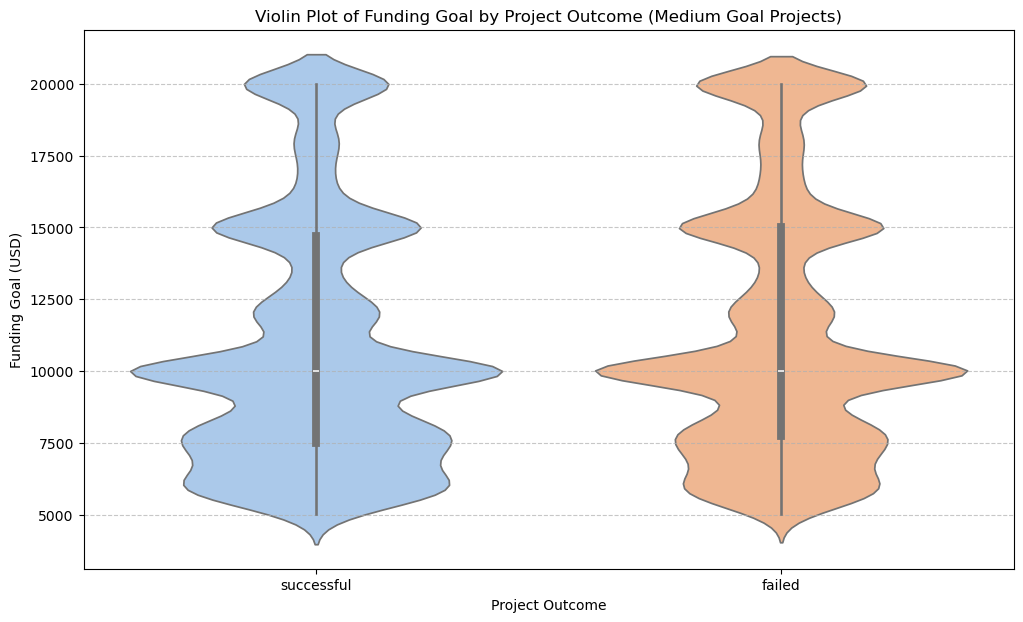

In [19]:
plt.figure(figsize=(12, 7))

sns.violinplot(
    data=df_completed,
    x='state',
    y='usd_goal_real',
    inner='box',
    palette='pastel',
    hue='state',
    legend=False
)
plt.title('Violin Plot of Funding Goal by Project Outcome (Medium Goal Projects)')
plt.ylabel('Funding Goal (USD)')
plt.xlabel('Project Outcome')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Key Findings**

- The violin plot shows that both successful and failed projects within the Medium category exhibit similar central distributions, with strong density around the \$8,000-\$12,000 range.

- Clear clustering is visible near round-number targets, particularly around \$10,000 and \$15,000, suggesting that creators tend to select commonly adopted or psychologically attractive funding levels.

- However, failed projects display slightly greater density toward the upper end of the Medium interval, again confirming that relatively higher funding targets within this range may be associated with lower success rates.

#### 2.1.3 Public Engagement Pattern

The number of backers reflects the level of public engagement and plays a central role in crowdfunding success. So understanding **how supporter participation is distributed** helps reveal whether campaign success is broadly distributed or concentrated among a small number of highly supported projects.

A log1p transformation was applied to the backer variables to address strong right-skewness while safely handling zero values. Unlike a standard logarithmic transformation, log1p (log(1 + x)) avoids undefined results when x equals zero and preserves interpretability for larger values.


/var/folders/2s/2f5vr80n5v3dkqq95t3s_fcm0000gn/T/ipykernel_28150/917116669.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_medium['log_backers'] = np.log1p(df_medium['backers'])


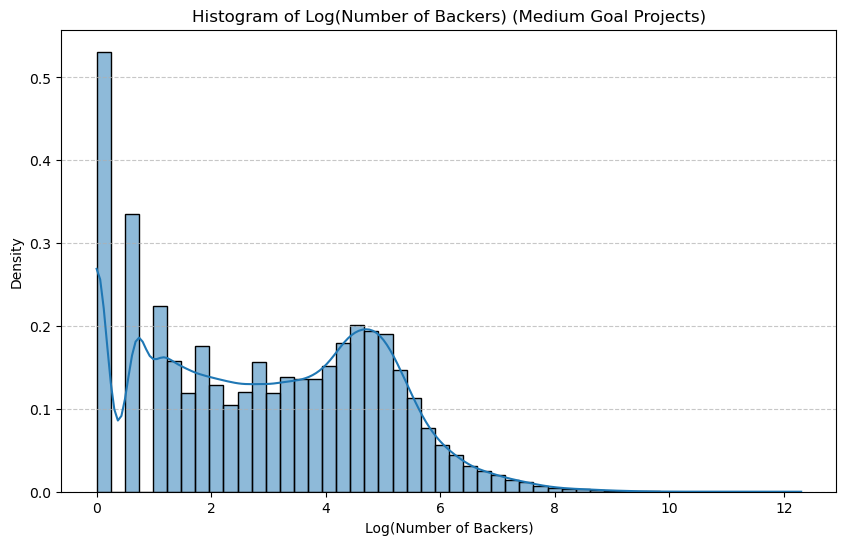

In [20]:
df_medium['log_backers'] = np.log1p(df_medium['backers'])

plt.figure(figsize=(10,6))
sns.histplot(x='log_backers',
             data=df_medium,
             bins=50,
             stat='density',
             kde=True,
             edgecolor='black')

plt.title('Histogram of Log(Number of Backers) (Medium Goal Projects)')
plt.xlabel('Log(Number of Backers)')
plt.ylabel('Density')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Key Findings**

- The log-transformed distribution highlights a strongly right-skewed engagement pattern.

- A substantial proportion of campaigns attract very few backers, primarily within the lower log range (fewer than 20 supporters). A secondary concentration appears around log values of 4 to 5, which roughly correspond to 50-150 backers, indicating that a subset of campaigns reaches moderate levels of engagement before the frequency declines sharply toward highly popular projects.

- This pattern suggests that supporter participation is not evenly distributed but instead concentrated among a limited group of campaigns.

#### 2.1.4 Funding Performance across Project Categories

To examine **whether funding performance differs across structurally distinct project major categories**, two contrasting major categories, **Art and Technology**, were selected for comparison.

The variable `usd_pledged_real` was used to represent actual funding performance. Same as before, due to its strong right-skewness, a logarithmic transformation log1p was applied to improve interpretability and stabilize the distribution for visualization.

/var/folders/2s/2f5vr80n5v3dkqq95t3s_fcm0000gn/T/ipykernel_28150/820407867.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_medium['log_pledged'] = np.log1p(df_medium['usd_pledged_real'])
/var/folders/2s/2f5vr80n5v3dkqq95t3s_fcm0000gn/T/ipykernel_28150/820407867.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pyramid['weight'] = df_pyramid['main_category'].map({'Art': -1, 'Technology': 1})


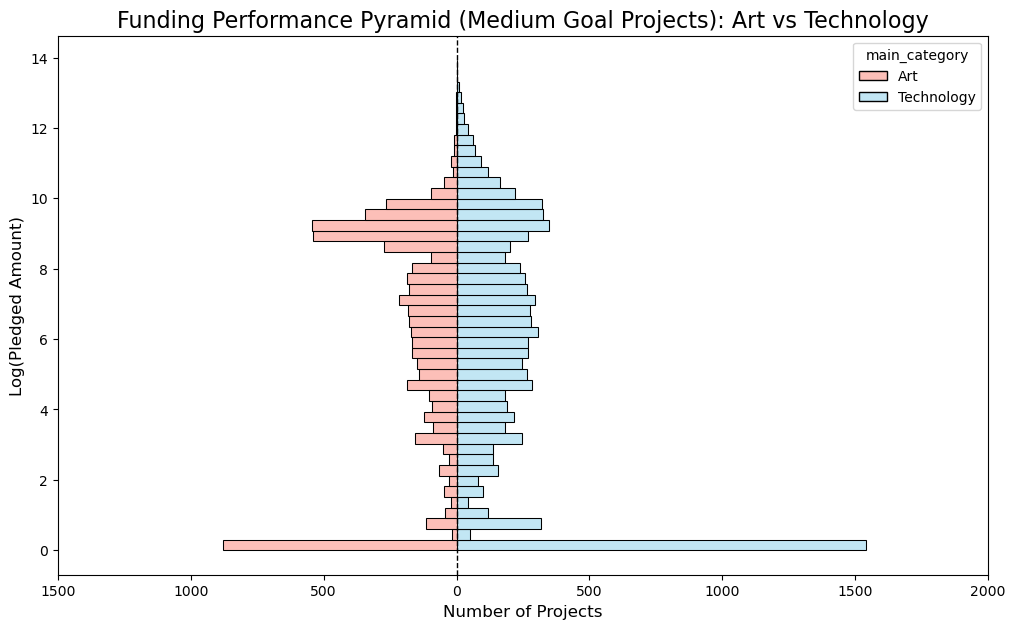

In [21]:
# Log transform pledged amount
df_medium['log_pledged'] = np.log1p(df_medium['usd_pledged_real'])

# Filter Art and Technology within Medium category
df_pyramid = df_medium[df_medium['main_category'].isin(['Art', 'Technology'])]

# Assign signed weights
df_pyramid['weight'] = df_pyramid['main_category'].map({'Art': -1, 'Technology': 1})

plt.figure(figsize=(12, 7))

# Create the pyramid chart
sns.histplot(
    data=df_pyramid,
    y='log_pledged',
    weights='weight',
    hue='main_category',
    binwidth=0.3,
    stat='count',
    palette={'Technology': 'skyblue', 'Art': 'salmon'},
)
plt.axvline(0, color='black', linewidth=1, linestyle='--')
plt.xlabel('Number of Projects', fontsize=12)
plt.ylabel('Log(Pledged Amount)', fontsize=12)
plt.title('Funding Performance Pyramid (Medium Goal Projects): Art vs Technology', fontsize=16)

# Make x-axis labels absolute
locs, labels = plt.xticks()
plt.xticks(locs, [str(int(abs(l))) for l in locs])

plt.show()

**Key Findings**

- The pyramid chart reveals structural differences in pledged funding between Art and Technology projects within the Medium goal category.

- Both categories exhibit strong concentration around log values of 8 to 10, corresponding approximately to \$3,000 to \$22,000 in pledged amounts.

- However, Technology projects display a broader distribution across pledged levels, indicating greater variability in funding outcomes. In particular, for log values above 10 (approximately above \$22,000), so Technology projects appear more frequently than Art projects at higher pledged levels. By contrast, Art projects appear more concentrated within a narrower mid-range of pledged amounts.

- These patterns suggest that while both categories attract moderate funding, Technology campaigns are more likely to achieve higher funding outcomes.

### 2.2 Trend & Category Comparison

#### 2.2.1 Campaign Success Over Time

To examine **how campaign success has evolved over time**, the launch year was extracted from the launched variable and yearly success rates (successful / (successful + failed)) were calculated as the proportion of successful campaigns within the Medium funding goal category. And only completed campaigns (successful and failed) were included in the success rate calculation to avoid distortion from ongoing or undefined projects.

/var/folders/2s/2f5vr80n5v3dkqq95t3s_fcm0000gn/T/ipykernel_28150/1168071343.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_completed['launch_year'] = df_completed['launched'].dt.year
/var/folders/2s/2f5vr80n5v3dkqq95t3s_fcm0000gn/T/ipykernel_28150/1168071343.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_completed['is_success'] = (df_completed['state'] == 'successful').astype(int)


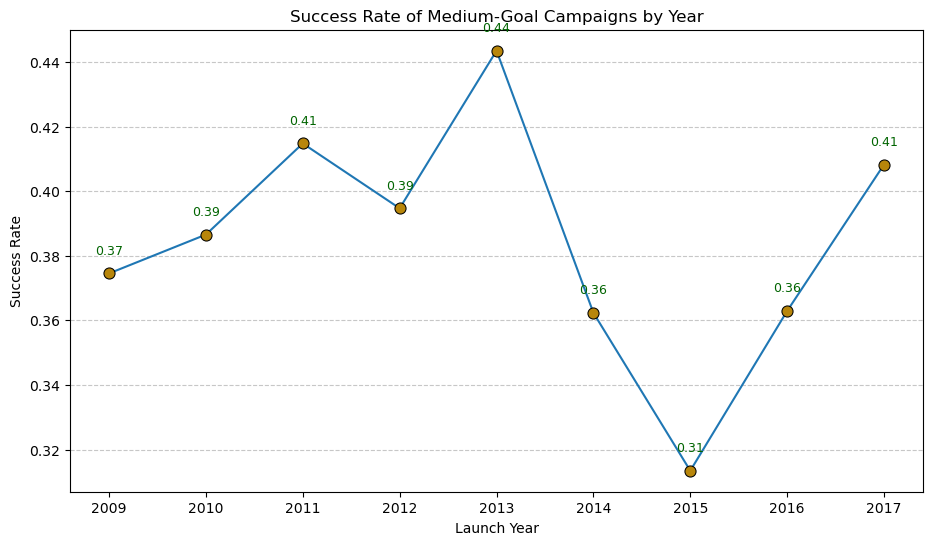

In [22]:
# Filter only completed projects (successful and failed)
df_completed = df_medium[df_medium['state'].isin(['successful', 'failed'])]

# Extract launch year
df_completed['launch_year'] = df_completed['launched'].dt.year

# Create success indicator
df_completed['is_success'] = (df_completed['state'] == 'successful').astype(int)

# Compute yearly success rate
yearly_success = df_completed.groupby('launch_year')['is_success'].mean().reset_index()

plt.figure(figsize=(11,6))

sns.lineplot(x='launch_year',
             y='is_success',
             data=yearly_success,
             marker='o',
             markerfacecolor='darkgoldenrod',
             markeredgecolor='black',
             markersize=8)

# Add value labels
for index, row in yearly_success.iterrows():
    plt.text(row['launch_year'],
             row['is_success'] + 0.005,
             f"{row['is_success']:.2f}",
             color='darkgreen',
             ha='center',
             va='bottom',
             fontsize=9)

plt.title('Success Rate of Medium-Goal Campaigns by Year')
plt.xlabel('Launch Year')
plt.ylabel('Success Rate')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Key Findings**

- The success rate of Medium-goal campaigns fluctuates over time, with relatively higher levels observed in the early years followed by a noticeable decline after 2013.

- This pattern suggests that achieving funding success may have become more challenging over time, potentially reflecting increased competition or changing platform dynamics.

#### 2.2.2 Success Across Categories

To examine **how success rates vary across different main categories within the Medium funding goal range**, same as before, the dataset was restricted to Medium-goal campaigns. Only completed projects (successful and failed) were retained to ensure accurate calculation of success rates. And a binary success indicator was created, and category-level success rates were computed as the proportion of successful campaigns within each main category.

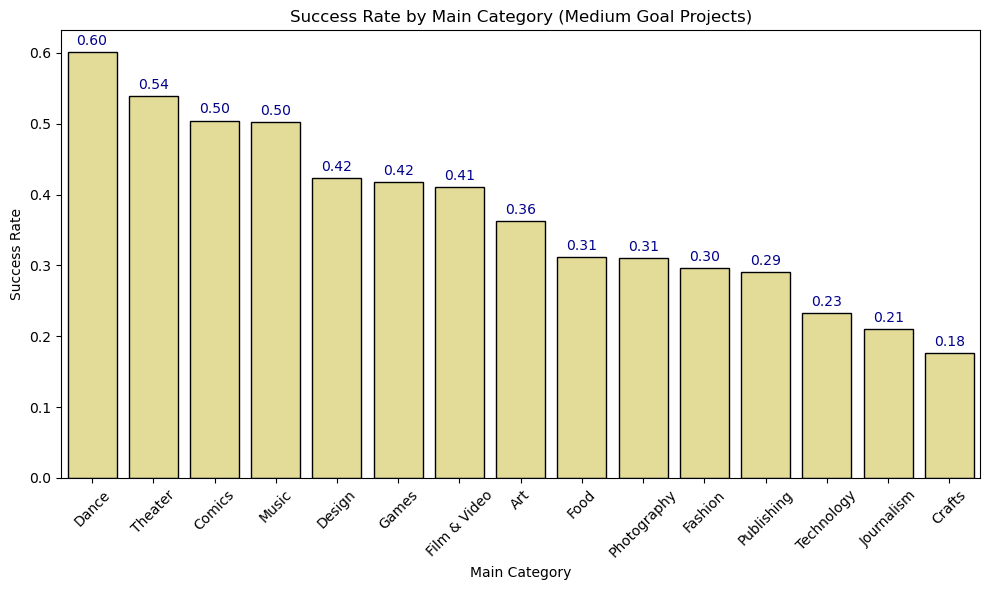

In [23]:
# Compute success rate by category
category_success = (df_completed.groupby('main_category')['is_success'].mean().reset_index(name='success_rate'))

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=category_success,
    x='main_category',
    y='success_rate',
    edgecolor='black',
    color='khaki',
    order=category_success.sort_values(
        'success_rate', ascending=False
    )['main_category']
)

# Add value labels
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center',
                va='center',
                xytext=(0, 8),
                textcoords='offset points',
                fontsize=10,
                color='darkblue'
                )

plt.title('Success Rate by Main Category (Medium Goal Projects)')
plt.xlabel('Main Category')
plt.ylabel('Success Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Key Findings**

- Success rates vary substantially across main categories within the Medium funding goal range, ranging from approximately 18% to 60%.

- Dance (60%) and Theater (54%) exhibit the highest success rates, followed by Comics and Music (both around 50%). In contrast, Crafts (18%), Journalism (21%), and Technology (23%) show comparatively lower success probabilities.

- The wide variation across categories suggests that crowdfunding outcomes are strongly influenced by project type, with creative performance-oriented categories generally achieving higher funding success than product- or craft-oriented projects within this funding range.

#### 2.2.3 Campaign Volume and Success Rate Over Time

This analysis investigates the **relationship between campaign volume and success rate within the Medium funding goal category**. We used `df_completed` here, which contains only successful and failed campaigns as before. The launch year was extracted from the `launched` variable, and the data were grouped by year to compute the total number of completed campaigns (`size`) and the yearly success rate (`mean` of the binary success indicator).

In [24]:
# Create yearly summary
year_summary = (
    df_completed
    .groupby('launch_year')
    .agg(count=('is_success', 'size'),
         mean=('is_success', 'mean'))
    .reset_index()
)
year_summary['year_str'] = year_summary['launch_year'].astype(str)

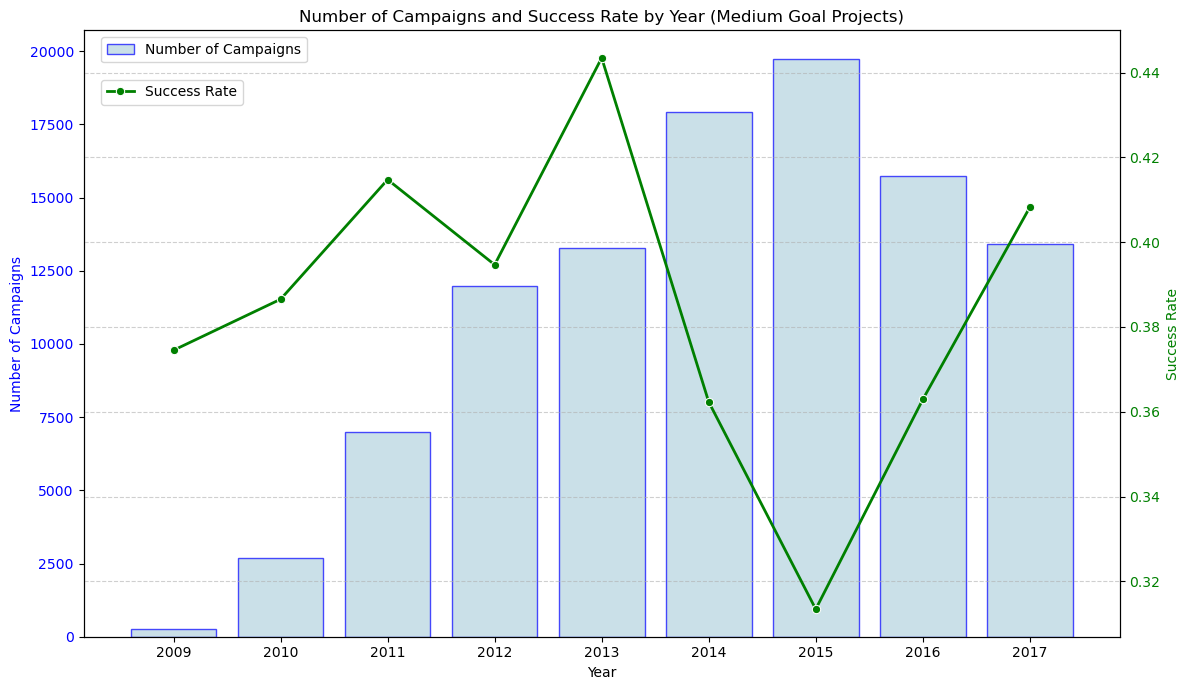

In [25]:
fig, ax1 = plt.subplots(figsize=(12, 7))

# Bar chart
sns.barplot(
    x='year_str',
    y='count',
    data=year_summary,
    ax=ax1,
    edgecolor='blue',
    color='lightblue',
    alpha=0.7,
    label='Number of Campaigns'
)

ax1.set_xlabel('Year')
ax1.set_ylabel('Number of Campaigns', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_title('Number of Campaigns and Success Rate by Year (Medium Goal Projects)')

# Second axis
ax2 = ax1.twinx()

sns.lineplot(
    x='year_str',
    y='mean',
    data=year_summary,
    ax=ax2,
    color='green',
    marker='o',
    linewidth=2,
    label='Success Rate'
)

ax2.set_ylabel('Success Rate', color='green')
ax2.tick_params(axis='y', labelcolor='green')

ax1.legend(loc='upper left', bbox_to_anchor=(0.01, 1))
ax2.legend(loc='upper left', bbox_to_anchor=(0.01, 0.93))

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

**Key Findings**

- The number of Medium-goal campaigns increased substantially between 2009 and 2015, rising from fewer than 1,000 campaigns in 2009 to nearly 20,000 campaigns at its peak in 2015.

- However, during this expansion period, the success rate fluctuated between approximately 37% and 45%, reaching a local peak around 2013 before declining sharply to nearly 31% in 2015.

- The inverse movement observed in 2014-2015, where campaign volume increased while success rates declined, suggests that intensified competition may have reduced the likelihood of funding success during periods of rapid growth of the platform.

### 2.3 Relationship & Performance Analysis

#### 2.3.1 Supporter Engagement and Funding Performance

To analyze the **relationship between supporter engagement and funding performance**, log-transformed values of `log_backers` and `log_pledged` are used within the Medium funding category.

The analysis is restricted to completed campaigns (successful and failed), with campaign outcome used to distinguish potential differences in the engagement-performance pattern.

In [26]:
df_completed.columns

Index(['ID', 'name', 'category', 'main_category', 'deadline', 'launched',
       'pledged', 'state', 'backers', 'country', 'usd_pledged_real',
       'usd_goal_real', 'goal_category', 'log_backers', 'log_pledged',
       'launch_year', 'is_success'],
      dtype='object')

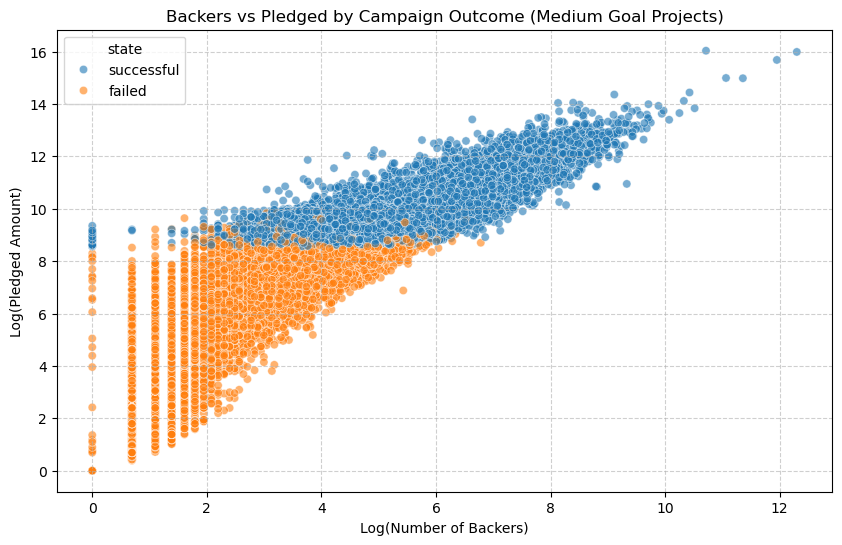

In [27]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df_completed,
    x='log_backers',
    y='log_pledged',
    hue='state',
    alpha=0.6
)
plt.title('Backers vs Pledged by Campaign Outcome (Medium Goal Projects)')
plt.xlabel('Log(Number of Backers)')
plt.ylabel('Log(Pledged Amount)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**Key Findings**

- The scatter plot reveals a strong positive relationship between supporter engagement and pledged amount, indicating that higher backer participation is closely associated with greater funding performance.

- Successful campaigns are consistently positioned above failed campaigns at comparable levels of backer engagement, suggesting higher funding efficiency among successful projects. So failed campaigns rarely achieve very high funding amounts, whereas successful campaigns reach substantially higher pledged levels.

#### 2.3.2 Key Performance-related Metrics

We want to compare **how key performance-related metrics differ between successful and failed campaigns within the Medium funding category**.

Selected variables (backers, pledged amount, funding goal, and pledged-to-goal ratio) were standardized using a global z-score transformation, and group-level mean deviations were computed separately for successful and failed campaigns.

/var/folders/2s/2f5vr80n5v3dkqq95t3s_fcm0000gn/T/ipykernel_28150/3499692866.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_completed['pledged_goal_ratio'] = (df_completed['usd_pledged_real'] / df_completed['usd_goal_real'])


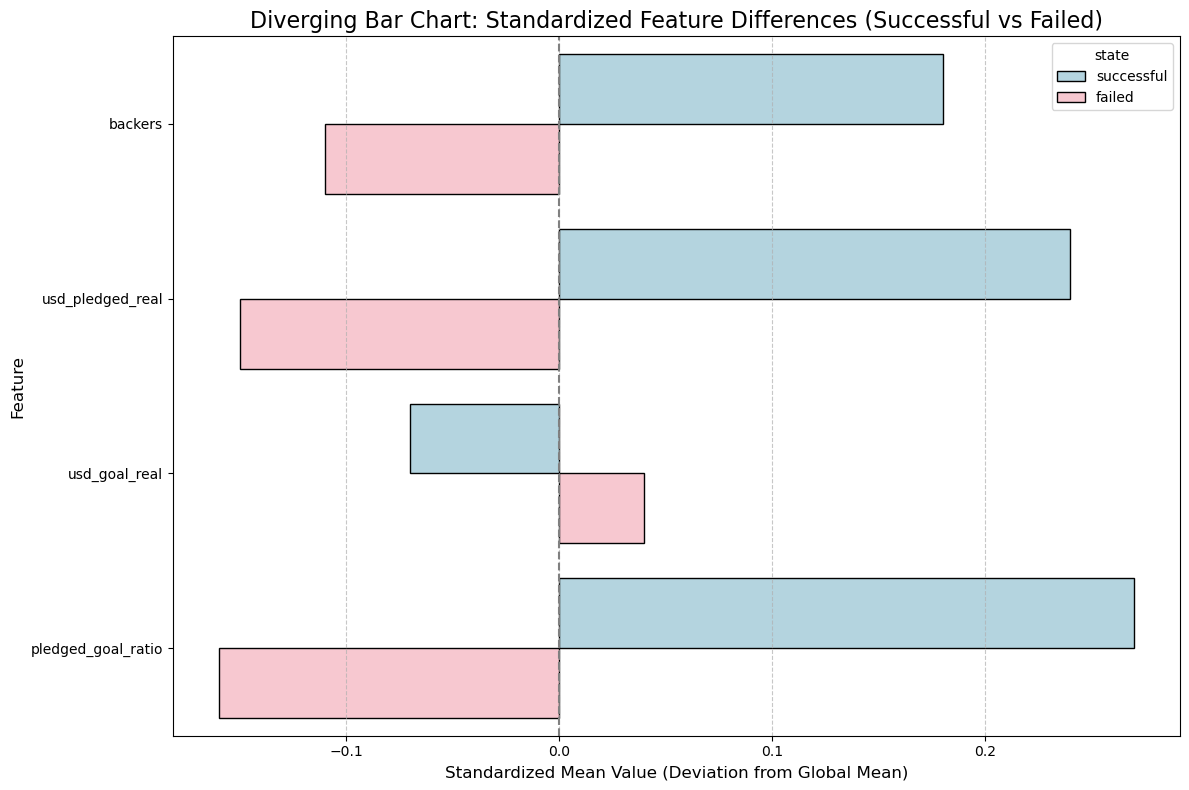

In [28]:
from sklearn.preprocessing import StandardScaler

df_completed['pledged_goal_ratio'] = (df_completed['usd_pledged_real'] / df_completed['usd_goal_real'])

# Select features
features = [
    'backers',
    'usd_pledged_real',
    'usd_goal_real',
    'pledged_goal_ratio'
]
df_features = df_completed[['state'] + features].copy()

# Initialize StandardScaler
scaler = StandardScaler()
df_features[features] = scaler.fit_transform(df_features[features])

# Calculate the mean of the features grouped by 'state'
df_diverging = (
    df_features
    .groupby('state')[features]
    .mean()
    .round(2)
    .T
    .reset_index()
    .rename(columns={'index':'feature'})
)

# Melt the DataFrame to long format for easier plotting with seaborn
df_melted = df_diverging.melt(
    id_vars=['feature'],
    value_vars=['successful','failed'],
    var_name='state',
    value_name='deviation'
)

# Create the diverging bar chart
plt.figure(figsize=(12,8))

sns.barplot(
    data=df_melted,
    x='deviation',
    y='feature',
    hue='state',
    palette={'successful':'lightblue','failed':'pink'},
    errorbar=None,
    dodge=True,
    edgecolor='black'
)
# Add a vertical line at x=0 to emphasize deviations (which is now the global mean)
plt.axvline(0, color='gray', linestyle='--', linewidth=1.5)

plt.title('Diverging Bar Chart: Standardized Feature Differences (Successful vs Failed)', fontsize=16)
plt.xlabel('Standardized Mean Value (Deviation from Global Mean)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Key Findings**

- The standardized diverging bar chart highlights clear structural differences between successful and failed campaigns across key performance metrics.

- Successful campaigns exhibit positive deviations from the global mean in backers, pledged amount, and pledged-to-goal ratio, with the largest difference observed in the pledged-to-goal ratio. In contrast, failed campaigns show negative deviations in these same variables, indicating systematically lower engagement and funding performance.

- Interestingly, failed campaigns display slightly higher standardized funding goals compared to successful campaigns, suggesting that higher goal-setting may be associated with lower likelihood of funding success within the Medium category.

## 3. Time Series Analysis

### 3.1 Moving Average

The time series variable will be constructed as **the monthly number of Medium-goal campaigns** by grouping all the projects according to their launch month. The datetime variable is converted to a monthly period format. We set the rolling moving average forecasts with window sizes ranging from 3 to 10 months. And the Mean Absolute Deviation (MAD) are calculated for each window size to help us select the optimal smoothing period.

In [29]:
# Make a copy
df_ts = df_medium.copy()

# Create month-year period
df_ts['month_year'] = df_ts['launched'].dt.to_period('M')

# Monthly total campaign count
monthly_count = (df_ts.groupby('month_year').size().to_frame(name='Campaign Count'))

# Convert index to timestamp
monthly_count.index = pd.PeriodIndex(monthly_count.index, freq='M')
monthly_count.index = monthly_count.index.to_timestamp()
monthly_count.head()

,Campaign Count
month_year,
2009-04-01,2
2009-05-01,7
2009-06-01,12
2009-07-01,13
2009-08-01,23


In [30]:
# Create moving average forecasts using rolling window sizes from 3 to 10
for window_size in range(3, 11):

    monthly_count[f'ma_{window_size}'] = (
        monthly_count['Campaign Count']
        .rolling(window=window_size, min_periods=window_size)
        .mean()
        .shift(1)
    )

    current_mad = (
        monthly_count['Campaign Count'] -
        monthly_count[f'ma_{window_size}']
    ).abs().mean()

    print(f"MAD of the {window_size}-Month Moving Average forecast for campaign count: {current_mad}")

MAD of the 3-Month Moving Average forecast for campaign count: 162.6181229773463
MAD of the 4-Month Moving Average forecast for campaign count: 173.79166666666666
MAD of the 5-Month Moving Average forecast for campaign count: 182.13267326732674
MAD of the 6-Month Moving Average forecast for campaign count: 190.32000000000005
MAD of the 7-Month Moving Average forecast for campaign count: 194.03607503607503
MAD of the 8-Month Moving Average forecast for campaign count: 202.79464285714286
MAD of the 9-Month Moving Average forecast for campaign count: 214.8167239404353
MAD of the 10-Month Moving Average forecast for campaign count: 227.5604166666667


The 3-month moving average yields the lowest MAD and therefore provides the most accurate forecast among the tested window sizes. Then we will use this window size to develop moving average forecasts.

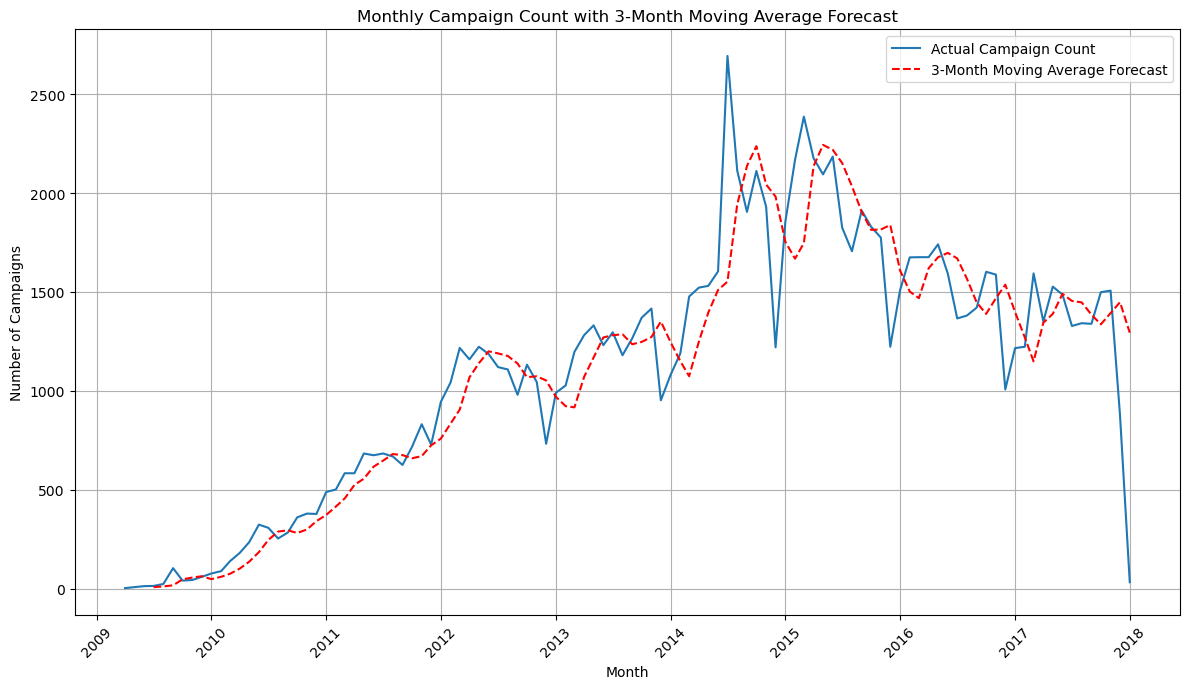

In [31]:
plt.figure(figsize=(12, 7))

# Calculate 3-month moving average forecast
monthly_count['ma_3'] = (
    monthly_count['Campaign Count']
    .rolling(window=3)
    .mean()
    .shift(1)
)

# Plot actual campaign count
sns.lineplot(
    data=monthly_count,
    x='month_year',
    y='Campaign Count',
    errorbar=None,
    label='Actual Campaign Count'
)

# Plot 3-month moving average forecast
sns.lineplot(
    data=monthly_count,
    x='month_year',
    y='ma_3',
    color='red',
    linestyle='--',
    label='3-Month Moving Average Forecast',
    errorbar=None
)

plt.title('Monthly Campaign Count with 3-Month Moving Average Forecast')
plt.xlabel('Month')
plt.ylabel('Number of Campaigns')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

**Key Findings**

- The monthly campaign count within the Medium funding category exhibits a strong upward trend from 2009 to approximately 2014-2015, indicating rapid growth in platform participation during the early expansion phase.

- After reaching a peak around 2015, campaign volume becomes more volatile and gradually declines through 2016-2017, suggesting a potential stabilization or cooling of platform activity.

- The 3-month moving average closely tracks the underlying trend while smoothing short-term fluctuations, effectively capturing both the rapid growth phase and the subsequent moderation in campaign volume.

### 3.2 Autoregression Model

Same as before, the monthly campaign count series will be used as the time series variable. A Partial Autocorrelation Function (PACF) plot is generated to determine the appropriate number of autoregressive lags. Then based on the significant lag structure, an AR(p) model will be estimated and evaluated using the statistical summary.

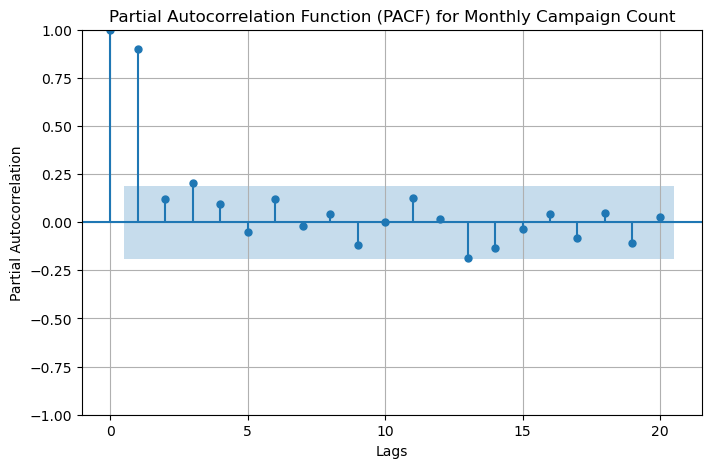

In [32]:
from statsmodels.graphics.tsaplots import plot_pacf

# Generate PACF plot
plt.figure(figsize=(8, 5))
# Limit lags to a safe maximum: min(20, (sample_size // 2) - 1)
plot_pacf(
    monthly_count['Campaign Count'],
    lags=min(20, (len(monthly_count) // 2) - 1),
    ax=plt.gca()
)
plt.title('Partial Autocorrelation Function (PACF) for Monthly Campaign Count')
plt.xlabel('Lags')
plt.ylabel('Partial Autocorrelation')
plt.grid(True)
plt.show()

Based on the PACF plot, only the first lag is statistically significant and exceeds the confidence bounds. Therefore, an AR(1) model is recommended for the monthly campaign count series.

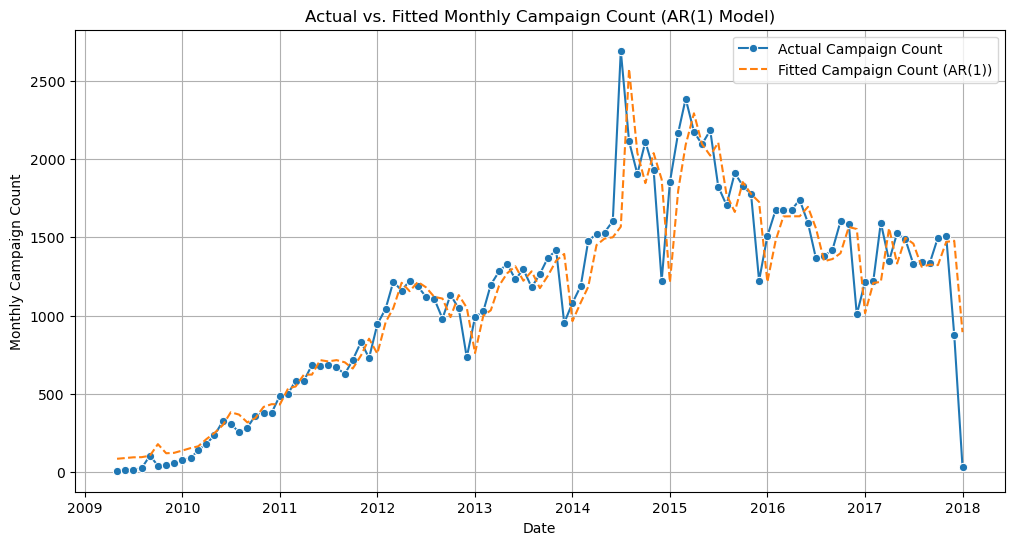

                            AutoReg Model Results                             
Dep. Variable:         Campaign Count   No. Observations:                  106
Model:                     AutoReg(1)   Log Likelihood                -722.805
Method:               Conditional MLE   S.D. of innovations            236.256
Date:                Fri, 29 May 2026   AIC                           1451.609
Time:                        18:20:05   BIC                           1459.571
Sample:                    05-01-2009   HQIC                          1454.835
                         - 01-01-2018                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                81.6366     46.582      1.753      0.080      -9.663     172.936
Campaign Count.L1     0.9267      0.036     25.409      0.000       0.855       0.998
                        

In [33]:
from statsmodels.tsa.ar_model import AutoReg

lags_value = 1  # Selected based on PACF

# Fit AR(1) model
model = AutoReg(monthly_count['Campaign Count'], lags=lags_value, seasonal=False)
model_fit = model.fit()

# Get fitted values
fitted_values_series = model_fit.fittedvalues.dropna()

# Plot actual vs fitted
plt.figure(figsize=(12, 6))

# Plot actuals
sns.lineplot(
    x=fitted_values_series.index,
    y=monthly_count['Campaign Count'].loc[fitted_values_series.index],
    label='Actual Campaign Count',
    marker='o'
)

# Plot fitted values
sns.lineplot(
    x=fitted_values_series.index,
    y=fitted_values_series,
    label='Fitted Campaign Count (AR(1))',
    linestyle='--'
)

plt.title('Actual vs. Fitted Monthly Campaign Count (AR(1) Model)')
plt.xlabel('Date')
plt.ylabel('Monthly Campaign Count')
plt.legend()
plt.grid(True)
plt.show()

# Display model summary
print(model_fit.summary())

**Key Findings**

- The AR(1) fitted values closely track the overall pattern of the actual monthly campaign counts, effectively capturing the sustained growth phase between 2009 and 2014 and the subsequent stabilization period. While the model smooths some extreme spikes and does not fully capture abrupt short-term fluctuations, it reproduces the underlying persistence in campaign activity. This suggests that recent historical participation plays a important role in predicting the current campaign volume, supporting the presence of strong short-term momentum in platform engagement.

- The AR(1) coefficient (0.9267, p < 0.001) is large and highly statistically significant, indicating strong persistence in monthly campaign counts. This implies that approximately 93% of the previous month's campaign volume carries over into the current month. However, the intercept term is not statistically significant, indicating that there is no strong evidence of a fixed baseline level independent of past values. Instead, the persistence effect captured by the lagged campaign count primarily explains the dynamics of the series.

- So overall, the results confirm that campaign participation exhibits substantial temporal dependence, consistent with gradual growth and stabilization patterns observed in platform lifecycle dynamics.

## Conclusion

Overall, the analysis shows that Kickstarter's Medium-goal campaigns experienced strong growth in the early years, especially between 2009 and 2014. After reaching a peak around 2014-2015, the number of campaigns began to stabilize and slightly decline. In addition, the time series results indicate that monthly campaign activity is strongly influenced by the previous month, meaning platform participation tends to follow short-term momentum rather than changing abruptly.

At the same time, in terms of performance, supporter engagement plays a central role in determining funding outcomes. Campaigns with more backers consistently achieve higher pledged amounts, and successful projects clearly outperform failed ones across key metrics such as pledged amount, number of backers, and pledged-to-goal ratio. These findings suggest that while platform growth is important, campaign success ultimately depends on building strong supporter engagement and setting realistic funding goals.

From a strategic perspective, Kickstarter may benefit from helping creators improve early engagement and goal-setting strategies. Providing clearer guidance on realistic funding targets and promoting tools that support audience building may could improve overall campaign success rates. As competition increases, campaigns that prepare stronger pre-launch engagement and communication strategies are more likely to achieve sustainable funding success.